In [9]:
import pandas as pd
df=pd.read_csv(r"df_final_demo.txt")


In [10]:
part1=pd.read_csv(r"df_final_web_data_pt_1.txt")


In [11]:
part2=pd.read_csv(r"df_final_web_data_pt_2.txt")


In [12]:
df_concated=pd.concat([part1,part2], ignore_index=True)


In [13]:
Variation=pd.read_csv(r"df_final_experiment_clients.txt")


In [14]:
merged = pd.merge(df, df_concated, on='client_id', how='inner')

In [15]:
full_df = pd.merge(merged, Variation, on='client_id', how='inner')


In [16]:
full_df.shape

(449831, 14)

In [17]:
full_df=full_df.drop_duplicates()

In [18]:
full_df = full_df[full_df["gendr"].isin(["M", "F"])]

In [19]:
full_df=full_df.dropna()

In [20]:
full_df.isna().sum()

client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            0
gendr               0
num_accts           0
bal                 0
calls_6_mnth        0
logons_6_mnth       0
visitor_id          0
visit_id            0
process_step        0
date_time           0
Variation           0
dtype: int64

In [21]:
primary_cilents=full_df.groupby('client_id').agg({'visit_id': 'count'}).sort_values(by='visit_id',ascending=False).head(10)
primary_cilents

,visit_id
client_id,
465007,72
9638063,71
4167815,61
5165430,60
2261960,59
7597144,58
711827,54
1595223,53
5601303,52


In [22]:
test_table=full_df[full_df['Variation'].str.lower() == 'test']
test_table

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,visitor_id,visit_id,process_step,date_time,Variation
22,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,391202328_71710993352,71954691_44810191073_495385,start,2017-04-06 19:03:46,Test
36,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,56607555_75044897582,247503697_11679931698_453228,confirm,2017-04-06 10:48:22,Test
37,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,56607555_75044897582,247503697_11679931698_453228,step_3,2017-04-06 10:45:09,Test
38,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,56607555_75044897582,247503697_11679931698_453228,step_2,2017-04-06 10:41:56,Test
39,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,56607555_75044897582,247503697_11679931698_453228,step_1,2017-04-06 10:39:23,Test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321304,7468138,18.0,222.0,61.0,F,3.0,209278.15,0.0,3.0,317123960_46820919455,769876461_30381166055_830233,step_2,2017-03-30 23:59:15,Test
321305,7468138,18.0,222.0,61.0,F,3.0,209278.15,0.0,3.0,317123960_46820919455,769876461_30381166055_830233,step_1,2017-03-30 23:58:51,Test
321306,7468138,18.0,222.0,61.0,F,3.0,209278.15,0.0,3.0,317123960_46820919455,769876461_30381166055_830233,start,2017-03-30 23:58:40,Test
321307,7468138,18.0,222.0,61.0,F,3.0,209278.15,0.0,3.0,317123960_46820919455,769876461_30381166055_830233,start,2017-03-30 23:55:11,Test


In [23]:
control_table = full_df[full_df['Variation'].str.lower() == 'control']
control_table

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,visitor_id,visit_id,process_step,date_time,Variation
23,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,432077852_35036160885,942996157_39527225999_589383,start,2017-06-14 14:22:31,Control
41,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0,667009768_32934260678,545534470_5635716155_93472,confirm,2017-03-29 11:57:25,Control
42,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0,667009768_32934260678,545534470_5635716155_93472,step_3,2017-03-29 11:55:31,Control
43,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0,667009768_32934260678,545534470_5635716155_93472,step_2,2017-03-29 11:55:27,Control
44,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0,667009768_32934260678,545534470_5635716155_93472,step_3,2017-03-29 11:54:55,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321283,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0,663474827_38847225720,923772865_74694577233_449836,confirm,2017-04-12 19:06:55,Control
321284,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0,663474827_38847225720,923772865_74694577233_449836,step_3,2017-04-12 19:05:14,Control
321285,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0,663474827_38847225720,923772865_74694577233_449836,step_2,2017-04-12 19:04:29,Control
321286,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0,663474827_38847225720,923772865_74694577233_449836,step_1,2017-04-12 19:04:07,Control


In [24]:
test_table.duplicated().sum()

np.int64(0)

In [25]:
#test_table completion rate
completed_clients_t=test_table[test_table["process_step"]=="confirm"]["client_id"].nunique()
total_clients_t=test_table["client_id"].nunique()
completion_rate_t = completed_clients_t / total_clients_t
completion_rate_t

0.688294805855423

In [26]:
#completion status YES/NO
completed_clients = test_table[test_table["process_step"] == "confirm"]["client_id"].unique()

test_table['completed_flag'] = test_table['client_id'].isin(completed_clients).astype(int)


C:\Users\prodd\AppData\Local\Temp\ipykernel_9824\1489378209.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_table['completed_flag'] = test_table['client_id'].isin(completed_clients).astype(int)


In [27]:
test_table['completed_flag'] = test_table['completed_flag'].map({1: 'yes', 0: 'no'})

C:\Users\prodd\AppData\Local\Temp\ipykernel_9824\1233729983.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_table['completed_flag'] = test_table['completed_flag'].map({1: 'yes', 0: 'no'})


In [28]:
test_table['completed_flag'].value_counts()

completed_flag
yes    89242
no     28215
Name: count, dtype: int64

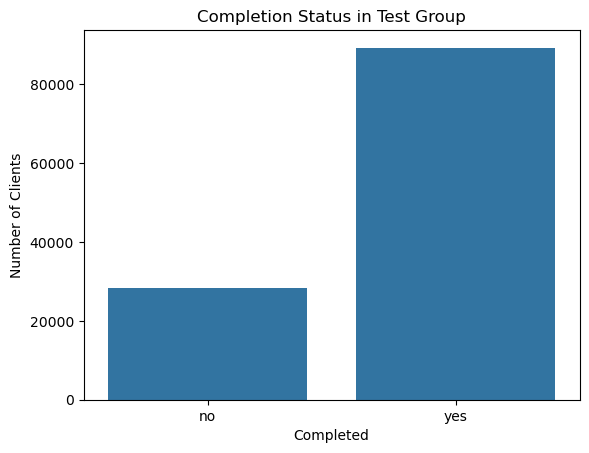

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot
sns.countplot(x='completed_flag', data=test_table)
plt.title("Completion Status in Test Group")
plt.xlabel("Completed")
plt.ylabel("Number of Clients")
plt.show()



In [30]:
#control_table
completed_clients_c=control_table[control_table["process_step"]=="confirm"]["client_id"].nunique()
total_clients_c=control_table["client_id"].nunique()
completion_rate_c = completed_clients_c / total_clients_c
completion_rate_c

0.649561629706034

In [31]:
#completion status YES/NO
completed_clients = control_table[control_table["process_step"] == "confirm"]["client_id"].unique()
control_table['completed_flag'] = control_table['client_id'].isin(completed_clients).astype(int)


C:\Users\prodd\AppData\Local\Temp\ipykernel_9824\105933298.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control_table['completed_flag'] = control_table['client_id'].isin(completed_clients).astype(int)


In [32]:
control_table['completed_flag'] =control_table['completed_flag'] .map({1: 'yes', 0: 'no'})

C:\Users\prodd\AppData\Local\Temp\ipykernel_9824\3746660001.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control_table['completed_flag'] =control_table['completed_flag'] .map({1: 'yes', 0: 'no'})


In [33]:
control_table['completed_flag'].value_counts()

completed_flag
yes    70436
no     21608
Name: count, dtype: int64

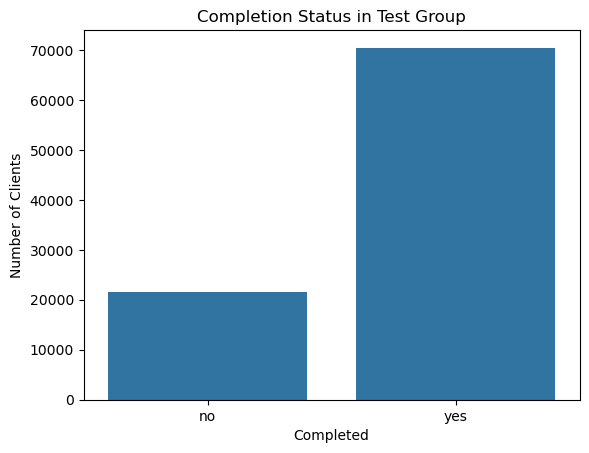

In [34]:
sns.countplot(x='completed_flag', data=control_table)
plt.title("Completion Status in Test Group")
plt.xlabel("Completed")
plt.ylabel("Number of Clients")
plt.show()

In [35]:
crosstab=pd.crosstab(test_table['process_step'], test_table['completed_flag'])


In [36]:
#chi_square
from scipy.stats import chi2_contingency
_,chi2_contingency,_,_=chi2_contingency(crosstab)
chi2_contingency

np.float64(0.0)

In [37]:
#person correlation
test_table['step_code'] = test_table['process_step'].astype('category').cat.codes
test_table['step_code'].corr(test_table['client_id'])

C:\Users\prodd\AppData\Local\Temp\ipykernel_9824\4185955481.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_table['step_code'] = test_table['process_step'].astype('category').cat.codes


np.float64(0.0017100371896456297)

In [38]:
#the process_step increaes the client_id increases

In [39]:
#H₀: Completion rate in test group ≤ control group
#H₁: Completion rate in test group > control group
#0.05

In [40]:
from statsmodels.stats.proportion import proportions_ztest

counts = [completed_clients_t, completed_clients_c]
number = [total_clients_t, total_clients_c]
proportions_ztest(counts, number, alternative='larger')


(np.float64(7.490116257936239), np.float64(3.4406316676867025e-14))

In [41]:
#reject the null hypothesis and completion rate test group is more


In [42]:
completed_t = (test_table['completed_flag'] == 'yes').sum()
total_t = test_table['completed_flag'].count()

completed_c = (control_table['completed_flag'] == 'yes').sum()
total_c = control_table['completed_flag'].count()

proportions_ztest([completed_t, completed_c], [total_t, total_c], alternative='larger')



(np.float64(-2.912382660616193), np.float64(0.9982065853347711))

In [43]:
#reject the null hypothesis and completion status for test group is more

In [44]:
# Step 1: Make a clean copy
test_table = test_table.copy()

# Step 2: Convert date_time in test_table, not merged
test_table['date_time'] = pd.to_datetime(test_table['date_time'], errors='coerce')

# Step 3: Sort and calculate time spent
sorted_test = test_table.sort_values(by=['visit_id', 'date_time'])

test_table['time_spent_minutes'] = (
    sorted_test.groupby('visit_id')['date_time']
    .diff()
    .abs()
    .dt.total_seconds() / 60
)

test_table['time_spent_minutes']
#diff() is difference between dates
#abs() convert -ve to +ve
#dt.total_seconds()/60 is to convert into minutes

22              NaN
36         3.216667
37         3.216667
38         2.550000
39         0.833333
            ...    
321304     0.400000
321305     0.183333
321306     3.483333
321307          NaN
321308    16.650000
Name: time_spent_minutes, Length: 117457, dtype: float64

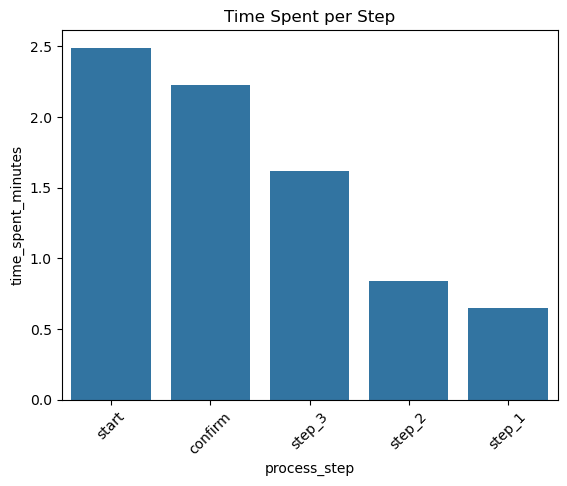

In [45]:
sns.barplot(x='process_step', y='time_spent_minutes', data=test_table,errorbar=None)
plt.title("Time Spent per Step")
plt.xticks(rotation=45)
plt.show()


In [46]:
test_table.groupby('process_step')['time_spent_minutes'].mean()
#. Average Time per Step

process_step
confirm    2.221794
start      2.490461
step_1     0.649628
step_2     0.837010
step_3     1.617487
Name: time_spent_minutes, dtype: float64

In [47]:
# Make a clean copy
control_table = control_table.copy()

# Step 2: Convert date_time in test_table, not merged
control_table['date_time'] = pd.to_datetime(control_table['date_time'], errors='coerce')

# Step 3: Sort and calculate time spent
sorted_control = control_table.sort_values(by=['visit_id', 'date_time'])

control_table['time_spent_minutes'] = (
    sorted_control.groupby('visit_id')['date_time']
    .diff()
    .abs()
    .dt.total_seconds() / 60
)
control_table['time_spent_minutes']

23             NaN
41        1.900000
42        0.066667
43        0.533333
44        0.216667
            ...   
321283    1.683333
321284    0.750000
321285    0.366667
321286    0.516667
321287         NaN
Name: time_spent_minutes, Length: 92044, dtype: float64

In [48]:
control_table.groupby('visit_id')['time_spent_minutes'].sum()
# Total Time per Visit

visit_id
100030127_47967100085_936361     0.000000
100037962_47432393712_705583     2.200000
10006594_66157970412_679648      5.900000
100071743_53464757454_616703     0.000000
10007589_47780784567_391490     12.016667
                                  ...    
999669588_11693809578_22026      0.000000
999707810_18368223868_308626     1.950000
999720028_44146654962_446209     0.300000
999814517_15202944548_822095     1.466667
999951892_54774917180_163890     0.000000
Name: time_spent_minutes, Length: 21507, dtype: float64

In [49]:
control_table.groupby('process_step')['time_spent_minutes'].mean()
#. Average Time per Step

process_step
confirm    2.246606
start      2.896607
step_1     0.741315
step_2     0.711418
step_3     1.593090
Name: time_spent_minutes, dtype: float64

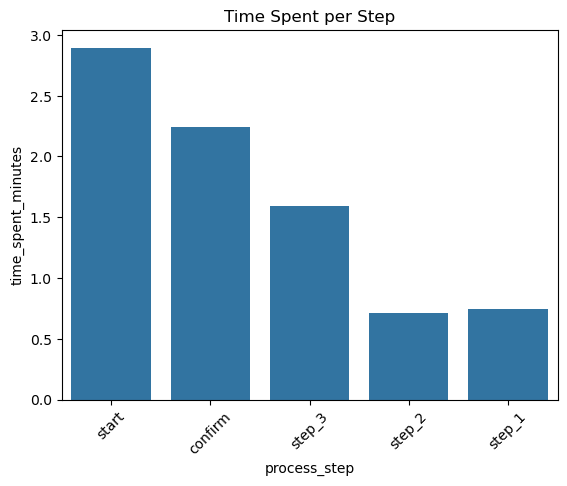

In [50]:
sns.barplot(x='process_step', y='time_spent_minutes', data=control_table,errorbar=None)
plt.title("Time Spent per Step")
plt.xticks(rotation=45)
plt.show()

In [51]:
c=pd.crosstab(test_table["process_step"],test_table["time_spent_minutes"])

In [52]:
#chi_square
from scipy.stats import chi2_contingency
_,chi2_contingency,_,_=chi2_contingency(c)
chi2_contingency

np.float64(0.0)

In [53]:
#cramers method
from scipy.stats.contingency  import association
association(c,method="cramer")

0.33514469308600325

In [54]:
#very weak association and also strength of association is weak between process step and time spent minutes.

In [55]:
#correlation pearson
#converting into numeric codes
test_table['step_code'] = test_table['process_step'].astype('category').cat.codes
test_table['step_code'].corr(test_table['time_spent_minutes'])


np.float64(-0.11513995726214515)

In [56]:
#spearman
test_table['step_code'].corr(test_table['time_spent_minutes'],method="spearman")

np.float64(-0.05447579485312878)

In [57]:
#higher step codes, tend to spend slightly less time per step.

In [58]:
# H₀: Mean time spent in test group <= mean time spent in control group

#H₁: Mean time spent in test group >= mean time spent in control group
#0.05

In [59]:
from scipy.stats import ttest_ind
#step-start
test_times = test_table[test_table["process_step"] == 'start']["time_spent_minutes"].dropna()
control_times = control_table[control_table["process_step"] == 'start']["time_spent_minutes"].dropna()

ttest_ind(test_times, control_times,alternative = "greater")


TtestResult(statistic=np.float64(-5.41558379700283), pvalue=np.float64(0.9999999691763325), df=np.float64(25209.0))

In [60]:
from scipy.stats import ttest_ind

steps = sorted_test['process_step'].dropna().unique()

for step in steps:
    test_times = test_table[test_table['process_step'] == step]['time_spent_minutes'].dropna()
    control_times = control_table[control_table['process_step'] == step]['time_spent_minutes'].dropna()
    stat, p_value = ttest_ind(test_times, control_times, alternative = "greater")
    print(f"Step: {step}")
    print(f"  statistic: {stat}")
    print(f"  p-value: {p_value}")


Step: start
  statistic: -5.41558379700283
  p-value: 0.9999999691763325
Step: step_1
  statistic: -5.543234115375369
  p-value: 0.9999999850697927
Step: step_2
  statistic: 7.995679047450023
  p-value: 6.631090008784395e-16
Step: step_3
  statistic: 1.0501210019653868
  p-value: 0.14683531678348802
Step: confirm
  statistic: -0.49933999466390766
  p-value: 0.6912278974521873


In [61]:
#rejected H0 and step2 spent more time in test group
